In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [20]:
df = pd.read_csv('resume.csv')

In [21]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2385 entries, 0 to 2384
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ID                        2385 non-null   int64  
 1   resume_text               2385 non-null   str    
 2   job_text                  2385 non-null   str    
 3   category                  2385 non-null   str    
 4   job_required_skills       2385 non-null   str    
 5   resume_skill_list         2385 non-null   str    
 6   ai_matched_skills         2385 non-null   str    
 7   ai_match_score            2385 non-null   float64
 8   skill_string_match_score  2385 non-null   float64
 9   fuzzy_match_score         2385 non-null   float64
dtypes: float64(3), int64(1), str(6)
memory usage: 186.5 KB


In [15]:
print(df.columns.to_list())

['ID', 'resume_text', 'job_text', 'category', 'job_required_skills', 'resume_skill_list', 'ai_matched_skills', 'ai_match_score', 'skill_string_match_score', 'fuzzy_match_score']


In [22]:
print("Shape:", df.shape)
print("\nDtypes:\n", df.dtypes)
print("\nFirst 3 rows:\n", df.head(3))

Shape: (2385, 10)

Dtypes:
 ID                            int64
resume_text                     str
job_text                        str
category                        str
job_required_skills             str
resume_skill_list               str
ai_matched_skills               str
ai_match_score              float64
skill_string_match_score    float64
fuzzy_match_score           float64
dtype: object

First 3 rows:
          ID                                        resume_text  \
0  16852973           HR ADMINISTRATOR/MARKETING ASSOCIATE\...   
1  22323967           HR SPECIALIST, US HR OPERATIONS      ...   
2  33176873           HR DIRECTOR       Summary      Over 2...   

                                            job_text category  \
0  Human Resources Business Partner\n------------...       HR   
1  Human Resources Business Partner\n------------...       HR   
2  Human Resources Business Partner\n------------...       HR   

                                 job_required_skills  \


=== MISSING VALUES ===
Empty DataFrame
Columns: [Missing Count, Missing %]
Index: []


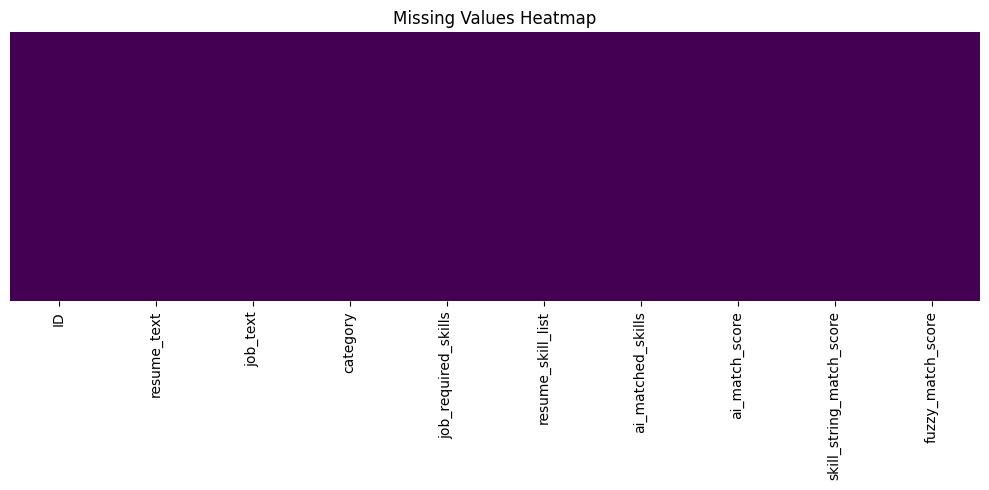

In [25]:
print("=== MISSING VALUES ===")
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(missing_df[missing_df['Missing Count'] > 0])

plt.figure(figsize=(10, 5))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title("Missing Values Heatmap")
plt.tight_layout()
plt.savefig("missing_heatmap.png")
plt.show()

In [27]:
numeric_cols = ['ai_match_score', 'skill_string_match_score', 'fuzzy_match_score']

df[numeric_cols].describe()

,ai_match_score,skill_string_match_score,fuzzy_match_score
count,2385.000000,2385.00000,2385.000000
mean,44.035862,11.55426,56.579698
std,24.628549,7.48703,6.778110
min,0.000000,0.00000,26.150000
25%,22.230000,6.06000,52.030000
50%,40.650000,10.00000,56.400000
75%,63.950000,15.79000,61.070000
max,100.000000,41.67000,84.410000


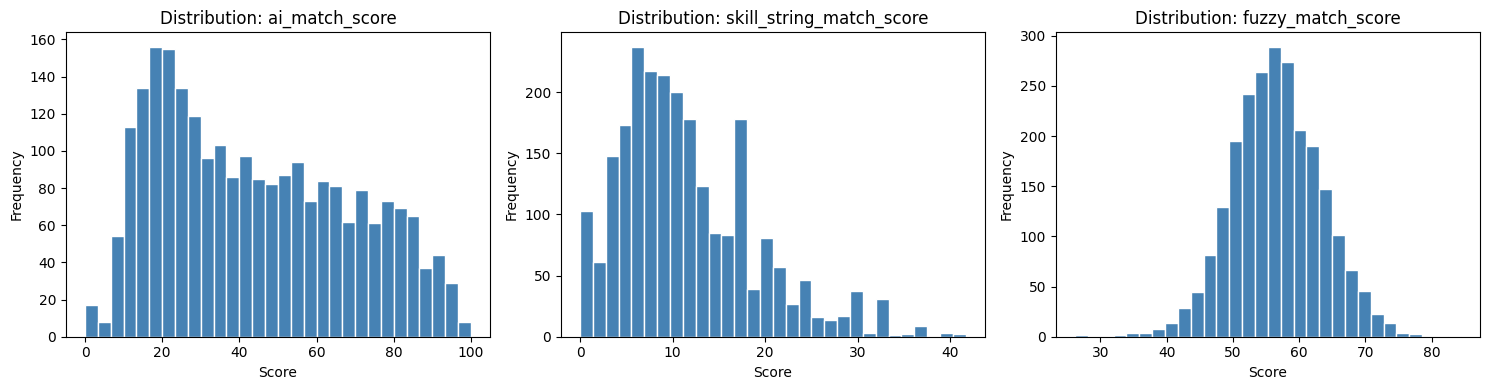

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, col in enumerate(numeric_cols):
    axes[i].hist(df[col], bins=30, color='steelblue', edgecolor='white')
    axes[i].set_title(f'Distribution: {col}')
    axes[i].set_xlabel('Score')
    axes[i].set_ylabel('Frequency')
plt.tight_layout()
plt.savefig("score_distributions.png")
plt.show()

Correlation Matrix:
                           ai_match_score  skill_string_match_score  \
ai_match_score                  1.000000                  0.614576   
skill_string_match_score        0.614576                  1.000000   
fuzzy_match_score               0.633746                  0.716332   

                          fuzzy_match_score  
ai_match_score                     0.633746  
skill_string_match_score           0.716332  
fuzzy_match_score                  1.000000  


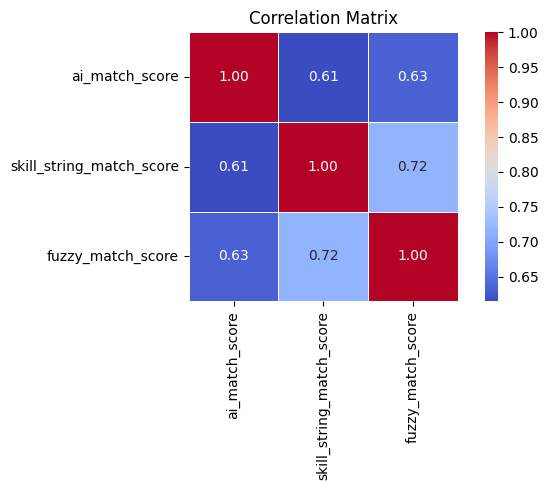

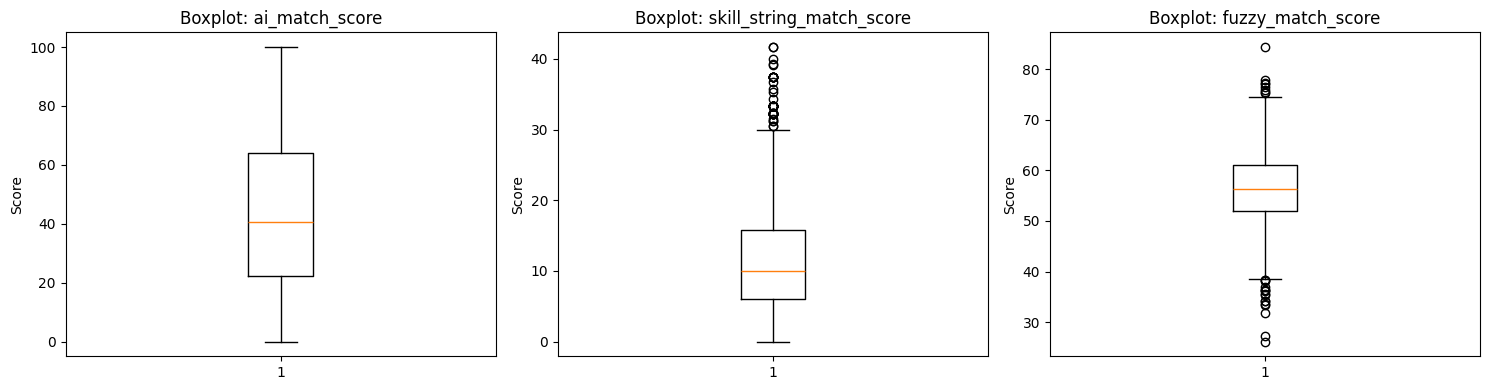


=== OUTLIERS (Z-score > 3) ===
ai_match_score: 0 outliers
skill_string_match_score: 17 outliers
fuzzy_match_score: 14 outliers


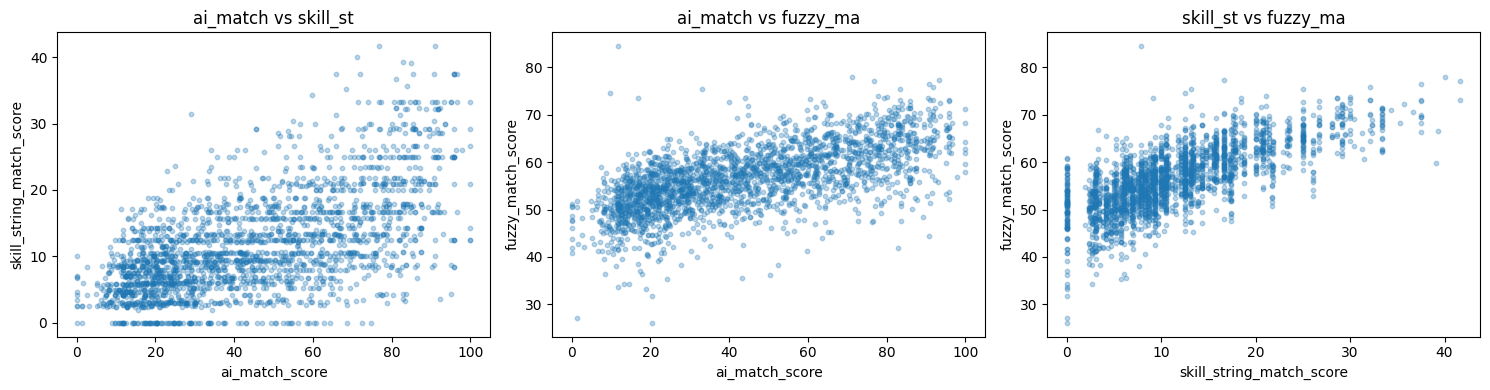

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

numeric_cols = ['ai_match_score', 'skill_string_match_score', 'fuzzy_match_score']

# --- Correlation Matrix ---
corr = df[numeric_cols].corr()
print("Correlation Matrix:\n", corr)

plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', square=True, linewidths=0.5)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.savefig("correlation_matrix.png")
plt.show()

# --- Boxplots for Outliers ---
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, col in enumerate(numeric_cols):
    axes[i].boxplot(df[col].dropna())
    axes[i].set_title(f'Boxplot: {col}')
    axes[i].set_ylabel('Score')
plt.tight_layout()
plt.savefig("boxplots.png")
plt.show()

# --- Z-score outlier count ---
print("\n=== OUTLIERS (Z-score > 3) ===")
for col in numeric_cols:
    z = np.abs(stats.zscore(df[col]))
    print(f"{col}: {(z > 3).sum()} outliers")

# --- Scatter plots between score pairs ---
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
pairs = [('ai_match_score', 'skill_string_match_score'),
         ('ai_match_score', 'fuzzy_match_score'),
         ('skill_string_match_score', 'fuzzy_match_score')]
for i, (x, y) in enumerate(pairs):
    axes[i].scatter(df[x], df[y], alpha=0.3, s=10)
    axes[i].set_xlabel(x)
    axes[i].set_ylabel(y)
    axes[i].set_title(f'{x[:8]} vs {y[:8]}')
plt.tight_layout()
plt.savefig("scatter_pairs.png")
plt.show()